In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



In [2]:
from src.config import *
from src.dataset import TankriDataset
from src.transforms import train_transform, val_transform
from src.models import SimpleCNN
from src.train import train
from src.evaluate import evaluate
from src.utils import set_seed

import json
import mlflow
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch import nn, optim

In [3]:
EPOCHS = 50

In [4]:
set_seed(RANDOM_SEED)

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [6]:
df = pd.read_csv(LABELS_FILE)

print(df.head())
counts = df["label"].value_counts()

# Keep only classes with at least 2 samples
valid_classes = counts[counts >= 2].index

df_filtered = df[df["label"].isin(valid_classes)].copy()
print("------------------------")
print(df_filtered.head())
print(f"Total Images : {len(df)}")
print(f"Total Classes : {df_filtered['label'].nunique()}")

   image label
0  1.png     𑚀
1  2.png     𑚁
2  3.png     𑚂
3  4.png     𑚃
4  5.png     𑚄
------------------------
   image label
0  1.png     𑚀
1  2.png     𑚁
2  3.png     𑚂
3  4.png     𑚃
4  5.png     𑚄
Total Images : 1060
Total Classes : 45


In [7]:
unique_labels = sorted(df_filtered["label"].unique())

label_to_idx = {
    label: idx
    for idx, label in enumerate(unique_labels)
}

idx_to_label = {
    idx: label
    for label, idx in label_to_idx.items()
}

NUM_CLASSES = len(unique_labels)

print(NUM_CLASSES)

45


In [25]:
print(df["label"].unique())
target_char = "𑚖"

matches = df.loc[df["label"] == target_char, "image"]

print(matches.tolist())
df["label"].value_counts()

['𑚀' '𑚁' '𑚂' '𑚃' '𑚄' '𑚅' '𑚆' '𑚇' '𑚈' '𑚉' '𑚀𑚫' '𑚊' '𑚋' '𑚌' '𑚍' '𑚎' '𑚏' '𑚐'
 '𑚑' '𑚒' '𑚓' '𑚔' '𑚕' '𑚖' '𑚗' '𑚘' '𑚙' '𑚚' '𑚛' '𑚜' '𑚝' '𑚞' '𑚟' '𑚠' '𑚡' '𑚢'
 '𑚣' '𑚤' '𑚥' '𑚦' '𑚧' '𑚨' '𑚩' '𑚪' '𑚀𑚬']
['24.png', '125.png', '126.png', '127.png', '128.png', '129.png', '488.png', '489.png', '490.png', '491.png', '492.png', '493.png', '494.png', '495.png', '496.png', '497.png', '498.png', '499.png', '500.png', '501.png', '502.png', '503.png', '504.png', '505.png', '506.png']


label
𑚠     33
𑚩     29
𑚕     28
𑚤     28
𑚙     28
𑚡     28
𑚋     28
𑚝     27
𑚔     27
𑚌     27
𑚜     27
𑚐     26
𑚨     26
𑚟     26
𑚚     25
𑚑     25
𑚖     25
𑚏     25
𑚧     25
𑚒     24
𑚞     24
𑚥     24
𑚢     23
𑚪     23
𑚀𑚬    23
𑚍     23
𑚛     22
𑚓     22
𑚦     22
𑚣     22
𑚈     21
𑚗     21
𑚃     21
𑚀     21
𑚀𑚫    21
𑚊     21
𑚎     21
𑚁     21
𑚉     20
𑚘     20
𑚇     19
𑚆     18
𑚄     18
𑚅     16
𑚂     16
Name: count, dtype: int64

In [9]:
train_df, val_df = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df_filtered["label"],
)

In [10]:
from src.models import ResNet18Model
from src.transforms import (
    train_transform_resnet,
    val_transform_resnet,
)
train_dataset = TankriDataset(
    dataframe=train_df,
    image_dir=IMAGES_DIR,
    label_to_idx=label_to_idx,
    transform=train_transform_resnet,
)

val_dataset = TankriDataset(
    dataframe=val_df,
    image_dir=IMAGES_DIR,
    label_to_idx=label_to_idx,
    transform=val_transform_resnet,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [11]:
model = ResNet18Model(
    num_classes=NUM_CLASSES,
    pretrained=True,
)

model = model.to(device)

In [12]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

model.layer4.0.conv1.weight
model.layer4.0.bn1.weight
model.layer4.0.bn1.bias
model.layer4.0.conv2.weight
model.layer4.0.bn2.weight
model.layer4.0.bn2.bias
model.layer4.0.downsample.0.weight
model.layer4.0.downsample.1.weight
model.layer4.0.downsample.1.bias
model.layer4.1.conv1.weight
model.layer4.1.bn1.weight
model.layer4.1.bn1.bias
model.layer4.1.conv2.weight
model.layer4.1.bn2.weight
model.layer4.1.bn2.bias
model.fc.weight
model.fc.bias


In [13]:
from torch.optim.lr_scheduler import CosineAnnealingLR
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
)


scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

In [14]:
import mlflow

mlflow.set_experiment("Tankri OCR")

<Experiment: artifact_location='file:///d:/Dev/tankri_ocr_proj/notebooks/mlruns/2', creation_time=1781272011663, experiment_id='2', last_update_time=1781272011663, lifecycle_stage='active', name='Tankri OCR', tags={}, trace_location=None, workspace='default'>

In [15]:
with mlflow.start_run(run_name="ResNet18_Baseline"):

    mlflow.log_param("model", "ResNet18")
    mlflow.log_param("pretrained", True)
    mlflow.log_param("learning_rate", 1e-4)
    mlflow.log_param("image_size", 224)
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("num_classes", NUM_CLASSES)
    mlflow.log_param("scheduler", "CosineAnnealingLR")
    mlflow.log_param("unfrozen_layers", "layer4+fc")

    history = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=EPOCHS,
        device=device,
        scheduler=scheduler,
        save_best=True,
        save_dir="models",
    )

    for epoch in range(EPOCHS):

        mlflow.log_metric(
            "train_loss",
            history["train_loss"][epoch],
            step=epoch,
        )

        mlflow.log_metric(
            "train_accuracy",
            history["train_accuracy"][epoch],
            step=epoch,
        )

        mlflow.log_metric(
            "val_loss",
            history["val_loss"][epoch],
            step=epoch,
        )

        mlflow.log_metric(
            "val_accuracy",
            history["val_accuracy"][epoch],
            step=epoch,
        )   

Epoch [1/50] | Train Loss: 3.6529 | Train Acc: 0.0719 | Val Loss: 3.5828 | Val Acc: 0.0849


Epoch [2/50] | Train Loss: 2.8964 | Train Acc: 0.3538 | Val Loss: 3.1372 | Val Acc: 0.2594


Epoch [3/50] | Train Loss: 2.3184 | Train Acc: 0.5236 | Val Loss: 2.5642 | Val Acc: 0.4811


Epoch [4/50] | Train Loss: 1.9090 | Train Acc: 0.6533 | Val Loss: 2.1946 | Val Acc: 0.5613


Epoch [5/50] | Train Loss: 1.5630 | Train Acc: 0.7193 | Val Loss: 2.0005 | Val Acc: 0.5708


...

Epoch [46/50] | Train Loss: 0.1200 | Train Acc: 0.9965 | Val Loss: 0.7580 | Val Acc: 0.8160


Epoch [47/50] | Train Loss: 0.1256 | Train Acc: 0.9906 | Val Loss: 0.7479 | Val Acc: 0.8113


Epoch [48/50] | Train Loss: 0.1214 | Train Acc: 0.9917 | Val Loss: 0.7528 | Val Acc: 0.8113


Epoch [49/50] | Train Loss: 0.1240 | Train Acc: 0.9917 | Val Loss: 0.7669 | Val Acc: 0.8160


Epoch [50/50] | Train Loss: 0.1190 | Train Acc: 0.9953 | Val Loss: 0.7478 | Val Acc: 0.8160


In [16]:
import numpy as np

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        predictions.extend(preds.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())

predictions = np.array(predictions)
true_labels = np.array(true_labels)

print("Per-class validation accuracy:")
print("-" * 60)

for cls in range(NUM_CLASSES):
    mask = true_labels == cls
    if mask.sum() == 0:
        continue

    correct = (predictions[mask] == cls).sum()
    total = mask.sum()
    accuracy = correct / total

    print(
        f"{idx_to_label[cls]}: {accuracy:.2%} ({correct}/{total})"
    )

print("-" * 60)

worst_classes = []
for cls in range(NUM_CLASSES):
    mask = true_labels == cls
    if mask.sum() == 0:
        continue

    correct = (predictions[mask] == cls).sum()
    total = mask.sum()
    accuracy = correct / total
    worst_classes.append((accuracy, cls, correct, total))

worst_classes.sort(key=lambda x: x[0])

print("Worst-performing classes:")
for accuracy, cls, correct, total in worst_classes[:10]:
    print(
        f"{idx_to_label[cls]}: {accuracy:.2%} ({correct}/{total})"
    )


Per-class validation accuracy:
------------------------------------------------------------
𑚀: 75.00% (3/4)
𑚀𑚫: 75.00% (3/4)
𑚀𑚬: 100.00% (5/5)
𑚁: 75.00% (3/4)
𑚂: 100.00% (3/3)
𑚃: 50.00% (2/4)
𑚄: 25.00% (1/4)
𑚅: 100.00% (3/3)
𑚆: 75.00% (3/4)
𑚇: 75.00% (3/4)
𑚈: 100.00% (4/4)
𑚉: 100.00% (4/4)
𑚊: 75.00% (3/4)
𑚋: 83.33% (5/6)
𑚌: 100.00% (5/5)
𑚍: 100.00% (5/5)
𑚎: 100.00% (4/4)
𑚏: 100.00% (5/5)
𑚐: 100.00% (5/5)
𑚑: 80.00% (4/5)
𑚒: 100.00% (5/5)
𑚓: 100.00% (4/4)
𑚔: 80.00% (4/5)
𑚕: 100.00% (6/6)
𑚖: 100.00% (5/5)
𑚗: 100.00% (4/4)
𑚘: 100.00% (4/4)
𑚙: 100.00% (6/6)
𑚚: 80.00% (4/5)
𑚛: 75.00% (3/4)
𑚜: 100.00% (5/5)
𑚝: 100.00% (5/5)
𑚞: 80.00% (4/5)
𑚟: 100.00% (5/5)
𑚠: 57.14% (4/7)
𑚡: 66.67% (4/6)
𑚢: 40.00% (2/5)
𑚣: 50.00% (2/4)
𑚤: 83.33% (5/6)
𑚥: 80.00% (4/5)
𑚦: 0.00% (0/4)
𑚧: 80.00% (4/5)
𑚨: 60.00% (3/5)
𑚩: 50.00% (3/6)
𑚪: 100.00% (5/5)
------------------------------------------------------------
Worst-performing classes:
𑚦: 0.00% (0/4)
𑚄: 25.00% (1/4)
𑚢: 40.00% (2/5)
𑚃: 50.00% (2/4)
𑚣: 50.00% (2/4)


In [17]:
import torch

torch.save(model.state_dict(), "resnet18_baseline.pth")

mlflow.log_artifact("resnet18_baseline.pth")

In [18]:
img, label = train_dataset[0]

print(img.shape)

torch.Size([3, 224, 224])


In [19]:
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Trainable: {trainable:,}")
print(f"Total: {total:,}")

Trainable: 8,416,813
Total: 11,199,597


False
19 13 120 99


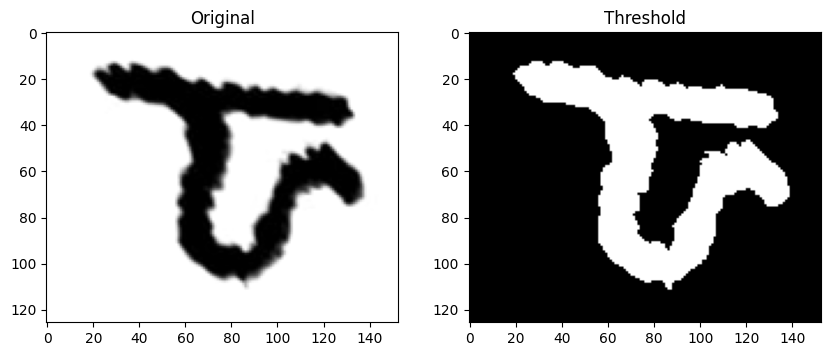

In [20]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(
    str(IMAGES_DIR / "1.png"),
    cv2.IMREAD_GRAYSCALE,
)

_, thresh = cv2.threshold(
    img,
    240,
    255,
    cv2.THRESH_BINARY_INV,
)

coords = cv2.findNonZero(thresh)

print(coords is None)

if coords is not None:
    x, y, w, h = cv2.boundingRect(coords)
    print(x, y, w, h)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(thresh, cmap="gray")
plt.title("Threshold")

plt.show()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
present_target_names = [idx_to_label[idx] for idx in present_labels]

print(
    classification_report(
        y_true,
        y_pred,
        labels=present_labels,
        target_names=present_target_names,
        digits=3,
        zero_division=0,
    )
)


              precision    recall  f1-score   support

           𑚀      0.750     0.750     0.750         4
          𑚀𑚫      1.000     0.750     0.857         4
          𑚀𑚬      0.833     1.000     0.909         5
           𑚁      0.500     0.750     0.600         4
           𑚂      0.500     1.000     0.667         3
           𑚃      1.000     0.500     0.667         4
           𑚄      1.000     0.250     0.400         4
           𑚅      0.600     1.000     0.750         3
           𑚆      0.750     0.750     0.750         4
           𑚇      0.750     0.750     0.750         4
           𑚈      0.800     1.000     0.889         4
           𑚉      0.667     1.000     0.800         4
           𑚊      0.750     0.750     0.750         4
           𑚋      1.000     0.833     0.909         6
           𑚌      1.000     1.000     1.000         5
           𑚍      1.000     1.000     1.000         5
           𑚎      0.800     1.000     0.889         4
           𑚏      1.000    

In [23]:
cm = confusion_matrix(y_true, y_pred)

class_accuracy = cm.diagonal() / cm.sum(axis=1)

for idx, acc in enumerate(class_accuracy):
    print(
        f"{idx_to_label[idx]} : {acc:.2%}"
    )

𑚀 : 75.00%
𑚀𑚫 : 75.00%
𑚀𑚬 : 100.00%
𑚁 : 75.00%
𑚂 : 100.00%
𑚃 : 50.00%
𑚄 : 25.00%
𑚅 : 100.00%
𑚆 : 75.00%
𑚇 : 75.00%
𑚈 : 100.00%
𑚉 : 100.00%
𑚊 : 75.00%
𑚋 : 83.33%
𑚌 : 100.00%
𑚍 : 100.00%
𑚎 : 100.00%
𑚏 : 100.00%
𑚐 : 100.00%
𑚑 : 80.00%
𑚒 : 100.00%
𑚓 : 100.00%
𑚔 : 80.00%
𑚕 : 100.00%
𑚖 : 100.00%
𑚗 : 100.00%
𑚘 : 100.00%
𑚙 : 100.00%
𑚚 : 80.00%
𑚛 : 75.00%
𑚜 : 100.00%
𑚝 : 100.00%
𑚞 : 80.00%
𑚟 : 100.00%
𑚠 : 57.14%
𑚡 : 66.67%
𑚢 : 40.00%
𑚣 : 50.00%
𑚤 : 83.33%
𑚥 : 80.00%
𑚦 : 0.00%
𑚧 : 80.00%
𑚨 : 60.00%
𑚩 : 50.00%
𑚪 : 100.00%


In [24]:
results = []

for idx, acc in enumerate(class_accuracy):
    results.append(
        (
            idx_to_label[idx],
            acc
        )
    )

results = sorted(
    results,
    key=lambda x: x[1]
)

print("Worst performing classes:\n")

for label, acc in results[:10]:
    print(label, f"{acc:.2%}")

Worst performing classes:

𑚦 0.00%
𑚄 25.00%
𑚢 40.00%
𑚃 50.00%
𑚣 50.00%
𑚩 50.00%
𑚠 57.14%
𑚨 60.00%
𑚡 66.67%
𑚀 75.00%
